<a href="https://colab.research.google.com/github/richards07-afk/Statistical-Theory/blob/main/SANTOS_MICE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


ANALYSIS FOR: TRAINING ERRORS
Assumption: Normality (Shapiro-Wilk) p = 0.2214
Assumption: Homogeneity (Levene's) p = 0.8731

ANOVA Results:
                           sum_sq    df         F    PR(>F)
C(AD_Status)                3.025   1.0  1.216080  0.278356
C(Treatment)               28.275   3.0  3.788945  0.019678
C(AD_Status):C(Treatment)   9.075   3.0  1.216080  0.319771
Residual                   79.600  32.0       NaN       NaN

Post-Hoc (Tukey HSD for Treatment):


/tmp/ipykernel_5710/2032153333.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene_p = stats.levene(*[group[dv].values for name, group in df.groupby(['AD_Status', 'Treatment'])])[1]


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2      1.5  0.172 -0.4223  3.4223  False
     1      3      0.9 0.5931 -1.0223  2.8223  False
     1      4     -0.7 0.7612 -2.6223  1.2223  False
     2      3     -0.6 0.8347 -2.5223  1.3223  False
     2      4     -2.2 0.0196 -4.1223 -0.2777   True
     3      4     -1.6 0.1314 -3.5223  0.3223  False
----------------------------------------------------


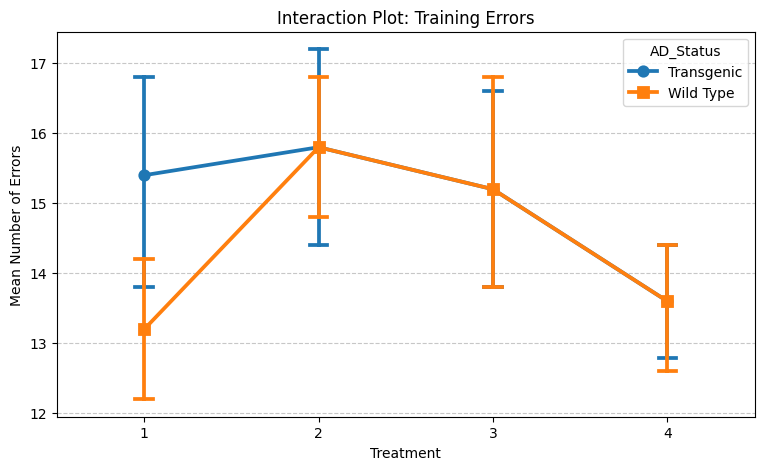


ANALYSIS FOR: MEMORY ERRORS
Assumption: Normality (Shapiro-Wilk) p = 0.2817
Assumption: Homogeneity (Levene's) p = 0.5722

ANOVA Results:
                            sum_sq    df          F        PR(>F)
C(AD_Status)               189.225   1.0  75.313433  6.449421e-10
C(Treatment)                14.475   3.0   1.920398  1.461176e-01
C(AD_Status):C(Treatment)    8.675   3.0   1.150912  3.436263e-01
Residual                    80.400  32.0        NaN           NaN

Post-Hoc (Tukey HSD for Treatment):


/tmp/ipykernel_5710/2032153333.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene_p = stats.levene(*[group[dv].values for name, group in df.groupby(['AD_Status', 'Treatment'])])[1]


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2      0.3  0.995 -3.0488 3.6488  False
     1      3      0.2 0.9985 -3.1488 3.5488  False
     1      4     -1.2 0.7699 -4.5488 2.1488  False
     2      3     -0.1 0.9998 -3.4488 3.2488  False
     2      4     -1.5 0.6269 -4.8488 1.8488  False
     3      4     -1.4 0.6762 -4.7488 1.9488  False
---------------------------------------------------


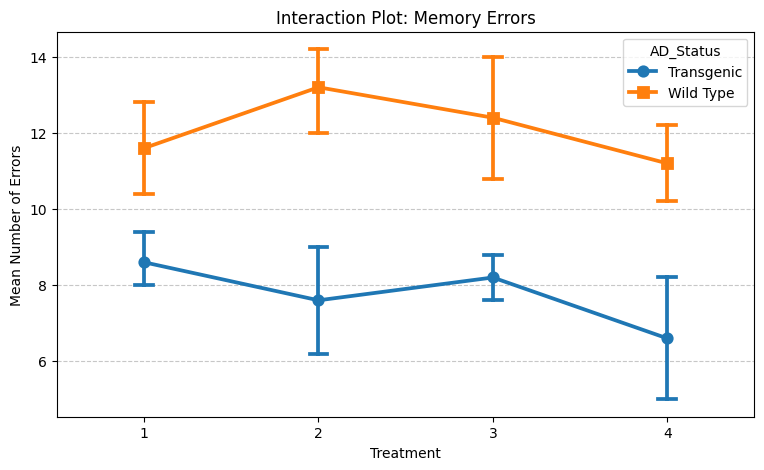

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. HARDCODED DATASET (From provided image) ---
data = {
    'AD_Status': [1]*20 + [2]*20,
    'Treatment': [1,1,1,1,1, 2,2,2,2,2, 3,3,3,3,3, 4,4,4,4,4] * 2,
    'Training': [12,15,13,12,14, 15,17,16,17,14, 13,14,18,15,16, 14,13,12,14,15,
                 17,16,17,14,13, 14,18,16,17,14, 13,14,18,15,16, 14,13,12,14,15],
    'Memory':   [10,12,13,10,13, 13,13,14,15,11, 12,11,15,10,14, 12,11,10,13,10,
                 9,8,10,8,8,     7,10,5,9,7,     8,7,9,8,9,      7,9,5,8,4]
}

df = pd.DataFrame(data)

# Ensure factors are categorical
df['AD_Status'] = df['AD_Status'].replace({1: 'Wild Type', 2: 'Transgenic'}).astype('category')
df['Treatment'] = df['Treatment'].astype('category')

# --- 2. ANALYSIS FUNCTION ---
def run_analysis(dv):
    print(f"\n{'='*60}\nANALYSIS FOR: {dv.upper()} ERRORS\n{'='*60}")

    # Fit Model
    formula = f'{dv} ~ C(AD_Status) * C(Treatment)'
    model = ols(formula, data=df).fit()

    # 1. Assumption: Normality
    shapiro_p = stats.shapiro(model.resid).pvalue
    print(f"Assumption: Normality (Shapiro-Wilk) p = {shapiro_p:.4f}")

    # 2. Assumption: Homogeneity
    levene_p = stats.levene(*[group[dv].values for name, group in df.groupby(['AD_Status', 'Treatment'])])[1]
    print(f"Assumption: Homogeneity (Levene's) p = {levene_p:.4f}")

    # 3. 2-Factor ANOVA
    print("\nANOVA Results:")
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

    # 4. Post-Hoc (Tukey HSD)
    print("\nPost-Hoc (Tukey HSD for Treatment):")
    posthoc = pairwise_tukeyhsd(df[dv], df['Treatment'], alpha=0.05)
    print(posthoc.summary())

    # 5. Interaction Plot
    plt.figure(figsize=(9, 5))
    sns.pointplot(data=df, x='Treatment', y=dv, hue='AD_Status', capsize=.1, markers=["o", "s"])
    plt.title(f'Interaction Plot: {dv} Errors')
    plt.ylabel('Mean Number of Errors')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Run for both Dependent Variables
run_analysis('Training')
run_analysis('Memory')